# Module 5 Homework: Neural Networks
#### **Breck, Fangyi, Luis**  
March 30, 2026

## Problem 1: Backpropagation by Hand (“pen and paper” → typed is preferred)

Consider a neural network with 2 inputs, a hidden layer with 2 neurons (sigmoid activation), and 1 output neuron (sigmoid activation). The weights are:

$$
W^{(1)} =
\begin{pmatrix}
0.5 & -0.3 \\
0.2 & 0.8
\end{pmatrix},
\quad
\mathbf{b}^{(1)} =
\begin{pmatrix}
0.1 \\
-0.1
\end{pmatrix}
$$

$$
\mathbf{w}^{(2)} =
\begin{pmatrix}
0.6 \\
-0.4
\end{pmatrix},
\quad
b^{(2)} = 0.2
$$

For input

$$
\mathbf{x} =
\begin{pmatrix}
1.0 \\
0.5
\end{pmatrix}
$$

with true label $y = 1$:

---

### (a) Forward Pass

Compute:

$$
z^{(1)}_1,\; z^{(1)}_2,\; h_1,\; h_2,\; z^{(2)},\; \hat{y}
$$

Show your work at each step.

---
#### Compute hidden layer pre-activation

$$
z^{(1)} = W^{(1)} \mathbf{x} + \mathbf{b}^{(1)}
$$

Compute each component:

$$
z^{(1)}_1 = 0.5 \cdot 1.0 + (-0.3) \cdot 0.5 + 0.1 = 0.5 - 0.15 + 0.1 = 0.45
$$

$$
z^{(1)}_2 = 0.2 \cdot 1.0 + 0.8 \cdot 0.5 + (-0.1) = 0.2 + 0.4 - 0.1 = 0.5
$$

$$
\boxed{ z^{(1)} =
\begin{pmatrix} 0.45 \\ 0.5 \end{pmatrix}}
$$

* Apply sigmoid activation to hidden layer (Sigmoid function: $ \sigma(z) = \frac{1}{1 + e^{-z}} $)

$$
h_1 = \sigma(0.45) = \frac{1}{1 + e^{-0.45}} \approx \boxed{0.6106}
$$

$$
h_2 = \sigma(0.5) = \frac{1}{1 + e^{-0.5}} \approx \boxed{0.6225}
$$

* Compute output pre-activation
$$
z^{(2)} = \mathbf{w}^{(2)\top} \mathbf{h} + b^{(2)}
$$

$$
z^{(2)} = 0.6 \cdot 0.6106 + (-0.4) \cdot 0.6225 + 0.2 \approx \boxed{0.317}
$$

* Apply sigmoid activation to output
$$
\hat{y} = \sigma(z^{(2)}) = \frac{1}{1 + e^{-0.317}} \approx \boxed{0.5786}
$$

---

### (b) Loss

Compute the binary cross-entropy loss for this single sample.

---
Binary cross-entropy loss:

$$
\mathcal{L} = -\left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
$$

Given:
- $y = 1$
- $\hat{y} \approx 0.5786$

Substitute:
$$
\mathcal{L} = -\left[ 1 \cdot \log(0.5786) + (1 - 1)\log(1 - 0.5786) \right]
$$

Simplify:

$$
\mathcal{L} = -\log(0.5786)
$$

Compute the value:
$$
\log(0.5786) \approx -0.547
$$

$$
\boxed{\mathcal{L} \approx 0.547}
$$

---

### (c) Backward Pass

Compute:

$$
\delta^{(2)},\quad
\frac{\partial L}{\partial \mathbf{w}^{(2)}},\quad
\frac{\partial L}{\partial b^{(2)}},\quad
\delta^{(1)},\quad
\frac{\partial L}{\partial W^{(1)}},\quad
\frac{\partial L}{\partial \mathbf{b}^{(1)}}
$$

---
For binary cross-entropy with sigmoid:

$$
\delta^{(2)} = \hat{y} - y
$$

$$
\boxed{\delta^{(2)} = 0.579 - 1 = -0.421}
$$

Gradients for output layer:
$$
\frac{\partial L}{\partial \mathbf{w}^{(2)}} = \delta^{(2)} \mathbf{h}
$$

$$
\frac{\partial L}{\partial w^{(2)}_1} = -0.421 \cdot 0.611 \approx -0.257
$$

$$
\frac{\partial L}{\partial w^{(2)}_2} = -0.421 \cdot 0.623 \approx -0.262
$$

$$
\boxed{
\frac{\partial L}{\partial \mathbf{w}^{(2)}} \approx
\begin{pmatrix}
-0.257 \\
-0.262
\end{pmatrix}
}
$$

Bias gradient:
$$
\boxed{
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)} = -0.421
}
$$

Hidden layer error
$$
\delta^{(1)} = (\mathbf{w}^{(2)} \delta^{(2)}) \odot \sigma'(z^{(1)})
$$

First compute:

$$
\mathbf{w}^{(2)} \delta^{(2)} =
\begin{pmatrix}
0.6 \\
-0.4
\end{pmatrix}
(-0.421)=
\begin{pmatrix}
-0.253 \\
0.168
\end{pmatrix}
$$

Now compute sigmoid derivatives:
$$
\sigma'(0.45) = 0.611(1 - 0.611) \approx 0.238
$$

$$
\sigma'(0.5) = 0.623(1 - 0.623) \approx 0.235
$$

Thus:
$$
\delta^{(1)}_1 = -0.253 \cdot 0.238 \approx -0.0602
$$

$$
\delta^{(1)}_2 = 0.168 \cdot 0.235 \approx 0.0395
$$

$$
\boxed{
\delta^{(1)} \approx
\begin{pmatrix}
-0.0602 \\
0.0395
\end{pmatrix}
}
$$

Gradients for first layer weights:
$$
\frac{\partial L}{\partial W^{(1)}} = \delta^{(1)} \mathbf{x}^T
$$

Compute each entry:
$$
\frac{\partial L}{\partial W^{(1)}_{11}} = -0.0602 \cdot 1.0 = -0.0602
$$

$$
\frac{\partial L}{\partial W^{(1)}_{12}} = -0.0602 \cdot 0.5 = -0.0301
$$

$$
\frac{\partial L}{\partial W^{(1)}_{21}} = 0.0395 \cdot 1.0 = 0.0395
$$

$$
\frac{\partial L}{\partial W^{(1)}_{22}} = 0.0395 \cdot 0.5 = 0.0198
$$

$$
\boxed{
\frac{\partial L}{\partial W^{(1)}} \approx
\begin{pmatrix}
-0.0602 & -0.0301 \\
0.0395 & 0.0198
\end{pmatrix}
}
$$

Gradients for first layer bias
$$
\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \delta^{(1)}
$$

$$
\boxed{
\frac{\partial L}{\partial \mathbf{b}^{(1)}} \approx
\begin{pmatrix}
-0.0602 \\
0.0395
\end{pmatrix}
}
$$

---

### (d) Update

If the learning rate is:

$$
\eta = 0.1
$$

write out the updated values of $\mathbf{w}^{(2)}$ and $b^{(2)}$ after one gradient descent step.

---

Gradient descent update rule:
$$
\theta_{\text{new}} = \theta_{\text{old}} - \eta \frac{\partial L}{\partial \theta}
$$

Update for $\mathbf{w}^{(2)}$
$$
\mathbf{w}^{(2)}_{\text{new}} = \mathbf{w}^{(2)} - \eta \frac{\partial L}{\partial \mathbf{w}^{(2)}}
$$

$$
=\begin{pmatrix}0.6 \\-0.4\end{pmatrix}-0.1
\begin{pmatrix}
-0.257 \\-0.262
\end{pmatrix}
$$

$$
=\begin{pmatrix}
0.6 + 0.0257 \\
-0.4 + 0.0262
\end{pmatrix}
=\begin{pmatrix}
0.626 \\
-0.374
\end{pmatrix}
$$

$$
\boxed{
\mathbf{w}^{(2)}_{\text{new}} \approx
\begin{pmatrix}
0.626 \\
-0.374
\end{pmatrix}
}
$$

Update for $b^{(2)}$
$$
b^{(2)}_{\text{new}} = b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$$

$$
= 0.2 - 0.1(-0.421)
= 0.2 + 0.0421
= 0.242
$$

$$
\boxed{b^{(2)}_{\text{new}} \approx 0.242}
$$

---

### (e) Interpretation

Briefly explain:

- Why is it called “backpropagation”?  
- What is being propagated, and in what direction?

---
It's called backpropagation because errors are propagated backward through the network from the output layer to earlier layers. The quantity being propagated is the gradient of the loss with respect to each neuron’s pre-activation (the $\delta$ terms). This propagation follows the chain rule, allowing us to compute how each weight contributes to the final error. 

The direction is from the output layer back to the input layer, opposite the forward pass.

----

## Problem 2: Extending the From-Scratch Network

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams.update({'font.size': 13, 'figure.figsize': (8, 5)})

### **2(a)**

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = np.tanh(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def backward(X, y, y_hat, h, W2):
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - h**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

def binary_cross_entropy(y, yh):
    eps = 1e-12
    yh = np.clip(yh, eps, 1 - eps)
    return -np.mean(y * np.log(yh) + (1 - y) * np.log(1 - yh))

def train_network(X, y, H=4, lr=0.5, n_epochs=2000, seed=0, verbose=True, 
                  ndiv=500):
    N, D = X.shape
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, losses

def plot_xor_result(W1, b1, W2, b2, losses, title=''):
    """Plot loss curve and decision boundary for XOR."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(losses, 'k-', lw=1)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training loss')
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z, _ = forward(np.c_[xx.ravel(), yy.ravel()], W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter([0,1], [0,1], c='tab:blue', s=200, edgecolors='k', zorder=5)
    plt.scatter([0,1], [1,0], c='tab:red', s=200, edgecolors='k', zorder=5)
    plt.set_title('Decision boundary')
    
    y_pred, _ = forward(X_xor, W1, b1, W2, b2)
    fig.suptitle(f'{title}  |  predictions: {y_pred.round(2)}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [8]:
# The XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, H=4, lr=1.0, n_epochs=5000, seed=0, verbose=True
)

y_pred_xor, _ = forward(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)
print("\nFinal XOR predictions:")
print(np.round(y_pred_xor, 3))
print("True labels:")
print(y_xor)

  epoch     0  loss = 0.6948  acc = 50.00%
  epoch   500  loss = 0.0034  acc = 100.00%
  epoch  1000  loss = 0.0014  acc = 100.00%
  epoch  1500  loss = 0.0009  acc = 100.00%
  epoch  2000  loss = 0.0006  acc = 100.00%
  epoch  2500  loss = 0.0005  acc = 100.00%
  epoch  3000  loss = 0.0004  acc = 100.00%
  epoch  3500  loss = 0.0003  acc = 100.00%
  epoch  4000  loss = 0.0003  acc = 100.00%
  epoch  4500  loss = 0.0003  acc = 100.00%

Final XOR predictions:
[0. 1. 1. 0.]
True labels:
[0. 1. 1. 0.]


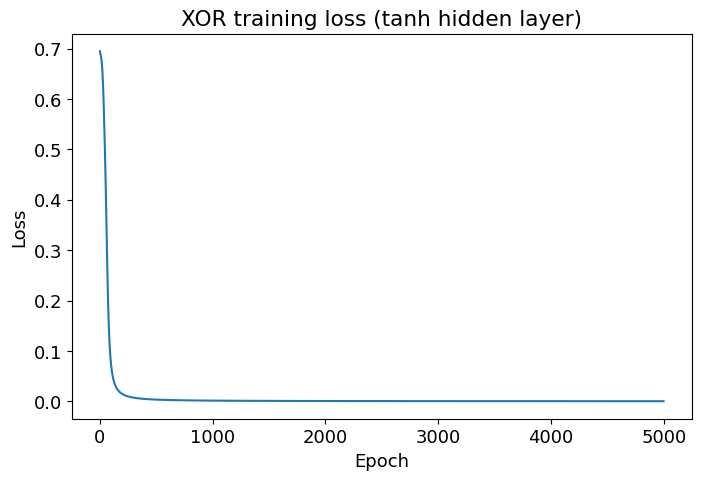

In [9]:
plt.plot(losses_xor)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR training loss (tanh hidden layer)")
plt.show()

---

### **2(b)**

In [11]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


W1_m, b1_m, W2_m, b2_m, losses_m = train_network(
    X_tr, y_tr, H=10, lr=0.1, n_epochs=5000, seed=0, verbose=True
)

y_hat_te, _ = forward(X_te, W1_m, b1_m, W2_m, b2_m)
y_pred_te = (y_hat_te > 0.5).astype(int)
acc_tanh = np.mean(y_pred_te == y_te)

print(f"Tanh network test accuracy: {acc_tanh:.2%}")

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_tr, y_tr)
acc_lr = clf_lr.score(X_te, y_te)

print(f"Logistic regression test accuracy: {acc_lr:.2%}")

  epoch     0  loss = 0.5910  acc = 68.57%
  epoch   500  loss = 0.2849  acc = 87.43%
  epoch  1000  loss = 0.2737  acc = 87.57%
  epoch  1500  loss = 0.2301  acc = 89.14%
  epoch  2000  loss = 0.1717  acc = 92.43%
  epoch  2500  loss = 0.1359  acc = 95.29%
  epoch  3000  loss = 0.1147  acc = 96.43%
  epoch  3500  loss = 0.1008  acc = 96.86%
  epoch  4000  loss = 0.0911  acc = 97.00%
  epoch  4500  loss = 0.0841  acc = 97.14%
Tanh network test accuracy: 95.33%
Logistic regression test accuracy: 86.67%


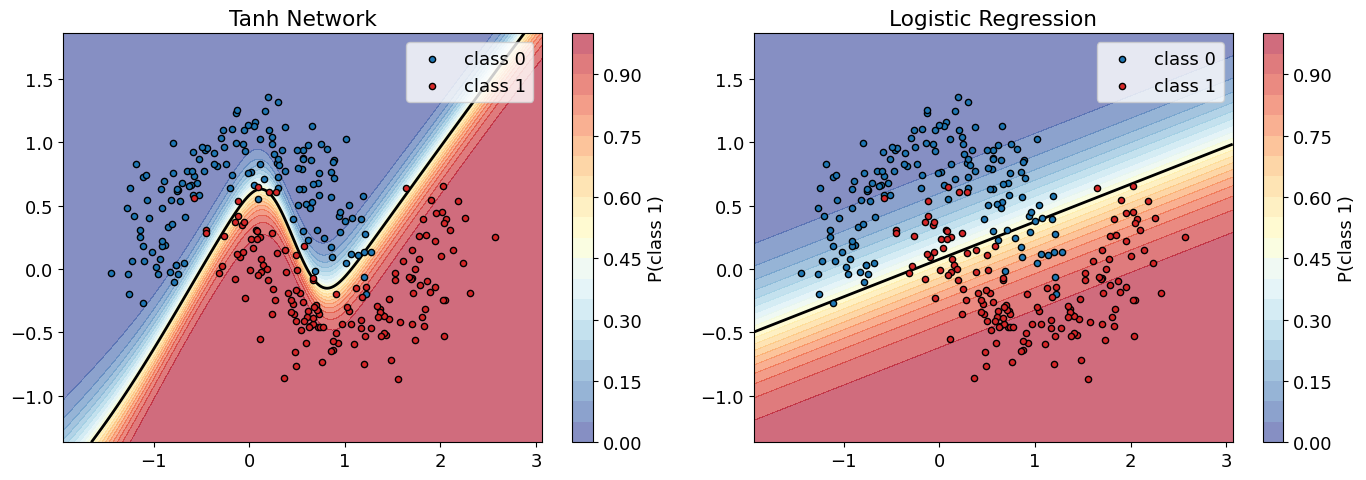

In [20]:
def plot_decision_boundary(X, y, forward_fn, clf, params, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2 = params
    probs, _ = forward_fn(grid, W1, b1, W2, b2)
    Z = probs.reshape(xx.shape)

    axes[0].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[0].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    axes[0].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[0].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[0].set_title(title1)
    axes[0].legend()
    plt.colorbar(axes[0].collections[0], ax=axes[0], label='P(class 1)')


    probs_lr = clf.predict_proba(grid)[:,1].reshape(xx.shape)

    axes[1].contourf(xx, yy, probs_lr, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, probs_lr, levels=[0.5], colors='k', linewidths=2)
    axes[1].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[1].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[1].set_title(title2)
    axes[1].legend()
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(class 1)')
    
    plt.tight_layout()
    plt.show()


plot_decision_boundary(X_te, y_te, forward, clf_lr, (W1_m, b1_m, W2_m, b2_m), "Tanh Network", "Logistic Regression")

---

### **2(C)**

In [21]:
def forward_2(X, W1, b1, W2, b2, W3, b3):
    z1 = X @ W1.T + b1
    h1 = np.tanh(z1)

    z2 = h1 @ W2.T + b2
    h2 = np.tanh(z2)

    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)

    return y_hat, h1, h2

def backward_2(X, y, y_hat, h1, h2, W2, W3):
    N = len(y)
    
    delta3 = y_hat - y
    dW3 = (h2.T @ delta3) / N
    db3 = np.mean(delta3)

    delta2 = np.outer(delta3, W3) * (1 - h2**2)
    dW2 = (delta2.T @ h1) / N
    db2 = np.mean(delta2, axis=0)

    delta1 = (delta2 @ W2) * (1 - h1**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)

    return dW1, db1, dW2, db2, dW3, db3

def train_network_2(X, y, H1=10, H2=5, lr=0.1, n_epochs=5000, seed=0,
                    verbose=True, ndiv=500):
    rng = np.random.default_rng(seed)
    N, D = X.shape

    W1 = rng.standard_normal((H1, D)) * 0.5
    b1 = np.zeros(H1)

    W2 = rng.standard_normal((H2, H1)) * 0.5
    b2 = np.zeros(H2)

    W3 = rng.standard_normal(H2) * 0.5
    b3 = 0.0

    losses = []

    for epoch in range(n_epochs):
        y_hat, h1, h2 = forward_2(X, W1, b1, W2, b2, W3, b3)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)

        dW1, db1_g, dW2, db2_g, dW3, db3_g = backward_2(
            X, y, y_hat, h1, h2, W2, W3
        )

        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        W3 -= lr * dW3
        b3 -= lr * db3_g

        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f"epoch {epoch:5d} | loss = {loss:.4f} | acc = {acc:.2%}")

    return W1, b1, W2, b2, W3, b3, losses

In [23]:
W1_2, b1_2, W2_2, b2_2, W3_2, b3_2, losses_2 = train_network_2(
    X_tr, y_tr, H1=10, H2=5, lr=0.1, n_epochs=5000, seed=0, verbose=True
)

y_hat_te_2, _, _ = forward_2(X_te, W1_2, b1_2, W2_2, b2_2, W3_2, b3_2)
y_pred_te_2 = (y_hat_te_2 > 0.5).astype(int)
acc_tanh_2 = np.mean(y_pred_te_2 == y_te)

print(f"Two-hidden-layer network test accuracy: {acc_tanh_2:.2%}")
print(f"One-hidden-layer tanh network test accuracy: {acc_tanh:.2%}")

epoch     0 | loss = 0.9457 | acc = 33.86%
epoch   500 | loss = 0.1991 | acc = 92.29%
epoch  1000 | loss = 0.0908 | acc = 97.29%
epoch  1500 | loss = 0.0662 | acc = 98.00%
epoch  2000 | loss = 0.0579 | acc = 97.86%
epoch  2500 | loss = 0.0538 | acc = 97.71%
epoch  3000 | loss = 0.0514 | acc = 98.29%
epoch  3500 | loss = 0.0499 | acc = 98.29%
epoch  4000 | loss = 0.0487 | acc = 98.43%
epoch  4500 | loss = 0.0478 | acc = 98.43%
Two-hidden-layer network test accuracy: 96.00%
One-hidden-layer tanh network test accuracy: 95.33%


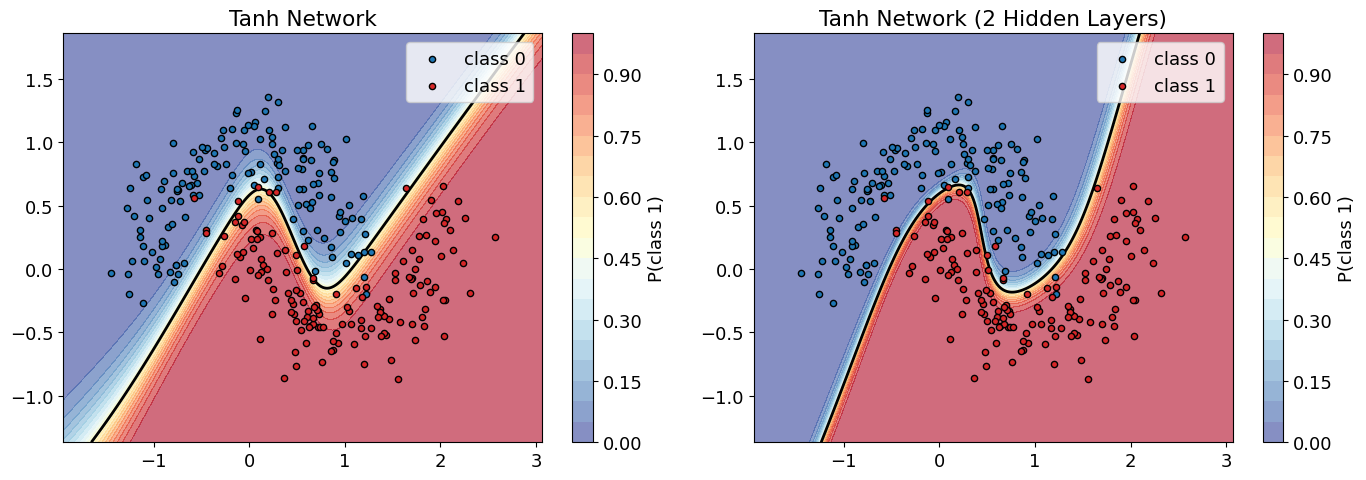

In [26]:
def plot_decision_boundary_2(X, y, forward_fn1, forward_fn2, params1, params2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2 = params1
    probs, _ = forward_fn1(grid, W1, b1, W2, b2)
    Z = probs.reshape(xx.shape)

    axes[0].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[0].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    axes[0].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[0].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[0].set_title(title1)
    axes[0].legend()
    plt.colorbar(axes[0].collections[0], ax=axes[0], label='P(class 1)')


    W1_2, b1_2, W2_2, b2_2, W3_2, b3_2 = params2
    probs2, _, _ = forward_fn2(grid, W1_2, b1_2, W2_2, b2_2, W3_2, b3_2)
    Z2 = probs2.reshape(xx.shape)

    axes[1].contourf(xx, yy, Z2, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, Z2, levels=[0.5], colors='k', linewidths=2)
    axes[1].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[1].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[1].set_title(title2)
    axes[1].legend()
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(class 1)')
    
    plt.tight_layout()
    plt.show()


plot_decision_boundary_2(X_te, y_te, forward, forward_2, (W1_m, b1_m, W2_m, b2_m), (W1_2, b1_2, W2_2, b2_2, W3_2, b3_2), "Tanh Network", "Tanh Network (2 Hidden Layers)")

---

### **2(d)**

**What was the hardest part of adding the second layer? What errors did you encounter? Relate this experience to why frameworks like PyTorch exist.**

The hardest part was keeping track of the propagation in the backward function. With one more layer, there are one more set of weights, so it is much harder to apply the chain rule and propagate with the right order of operations. The main errors happened when doing the hardes part mentioned above. It was confusing to match the size of the matrices when doing matrix multiplication. It was also easy to mix up which layer output should be used in the next propagation. Hence, frameworks like PyTorch are useful to save time from manually coding and to reduce errors, especially for more hidden layers or more complicated structures.

## Problem 3: PyTorch on Handwritten Digit Classification

In this problem you will apply PyTorch to a **multi-class classification task**: recognizing handwritten digits from the MNIST dataset. This extends what we did in lecture in two important ways:

1. The task has 10 classes instead of 2  
2. The input is image data with enough complexity that a neural network meaningfully outperforms a linear classifier  

### Load the MNIST dataset

```python
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True,
                             download=True, transform=transform)

mnist_test = datasets.MNIST('./data', train=False,
                            transform=transform)

```

### Important: multi-class changes

When moving from binary to multi-class classification, two things change:

- The output layer has **10 neurons** (one per class) instead of 1, and uses a **softmax** activation instead of sigmoid  
- The loss function is **cross-entropy loss** (`nn.CrossEntropyLoss` in PyTorch), which generalizes binary cross-entropy to multiple classes  

> **Note:**  
> `nn.CrossEntropyLoss` in PyTorch applies softmax internally, so your network’s final layer should be **linear** (no activation) when using this loss.


### **Part A: Baseline and first network**

**(a)** Visualize some of the data: plot a grid of example digit images (one per class).

**(b)** Train a logistic regression classifier (`sklearn`, on the flattened NumPy arrays) as a baseline.  
Report the test accuracy and plot the confusion matrix.  
Which digit pairs are most commonly confused?

**(c)** Build a PyTorch network with one hidden layer (**H = 128**, ReLU activation) and a linear output layer with 10 neurons.  
Train using `nn.CrossEntropyLoss` and the Adam optimizer for ~20 epochs with batch size 128.  
Report the test accuracy. How much does the neural network improve over logistic regression?

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim


torch.manual_seed(0)
np.random.seed(0)

# MNIST transform for PyTorch model
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

# Raw numpy versions for sklearn logistic regression
# Use the original pixel values scaled to [0,1]
X_train_np = mnist_train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train_np = mnist_train.targets.numpy()

X_test_np = mnist_test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test_np = mnist_test.targets.numpy()

#### Part A (a)

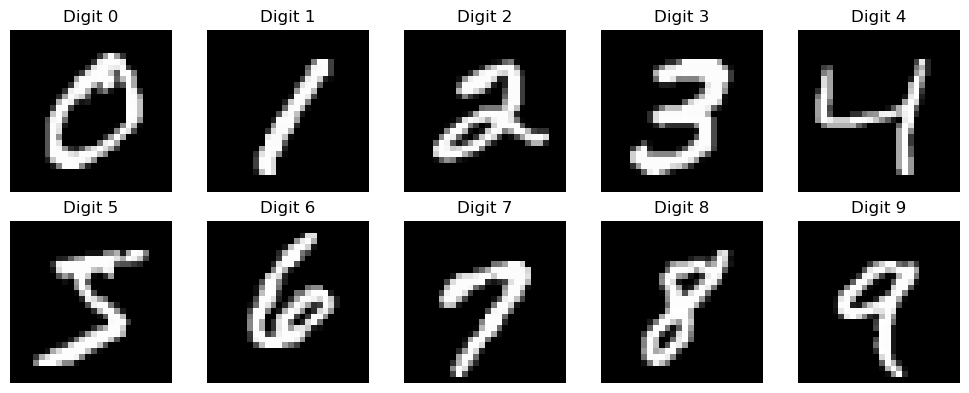

In [9]:
def plot_one_example_per_class(dataset):
    """
    Plot one example image for each digit class 0-9.
    Uses dataset.data and dataset.targets from MNIST.
    """
    images = dataset.data
    labels = dataset.targets

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()

    for digit in range(10):
        idx = (labels == digit).nonzero(as_tuple=True)[0][0].item()
        axes[digit].imshow(images[idx], cmap='gray')
        axes[digit].set_title(f"Digit {digit}")
        axes[digit].axis('off')

    plt.tight_layout()
    plt.show()

plot_one_example_per_class(mnist_train)

#### Part A (b)

In [10]:
# Logistic regression baseline
log_reg = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1
)

log_reg.fit(X_train_np, y_train_np)

y_pred_logreg = log_reg.predict(X_test_np)
logreg_acc = accuracy_score(y_test_np, y_pred_logreg)

print(f"Logistic Regression Test Accuracy: {logreg_acc:.4f}")

Logistic Regression Test Accuracy: 0.9256


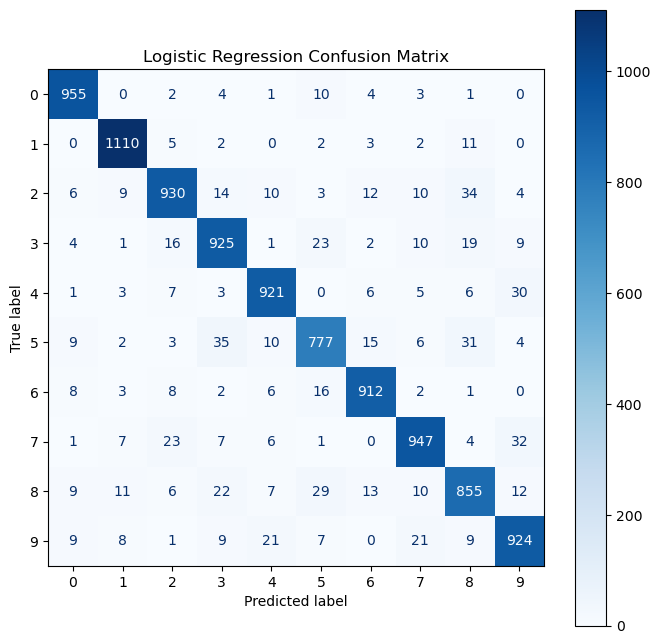

In [11]:
cm_logreg = confusion_matrix(y_test_np, y_pred_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [12]:
def most_confused_pairs(cm, top_k=10):
    cm_offdiag = cm.copy()
    np.fill_diagonal(cm_offdiag, 0)

    pairs = []
    for i in range(cm_offdiag.shape[0]):
        for j in range(cm_offdiag.shape[1]):
            if i != j:
                pairs.append((i, j, cm_offdiag[i, j]))

    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:top_k]

top_confusions = most_confused_pairs(cm_logreg, top_k=10)

print("Most commonly confused digit pairs (true -> predicted):")
for true_digit, pred_digit, count in top_confusions:
    print(f"{true_digit} -> {pred_digit}: {count}")

Most commonly confused digit pairs (true -> predicted):
5 -> 3: 35
2 -> 8: 34
7 -> 9: 32
5 -> 8: 31
4 -> 9: 30
8 -> 5: 29
3 -> 5: 23
7 -> 2: 23
8 -> 3: 22
9 -> 4: 21


#### Part A (c)

In [13]:
class MNISTNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)   # linear output, no softmax
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten 28x28 -> 784
        return self.net(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [16]:
num_epochs = 20

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, y_true_nn, y_pred_nn = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch  1/20 | Train Loss: 0.2997 | Train Acc: 0.9141 | Test Loss: 0.1624 | Test Acc: 0.9515
Epoch  2/20 | Train Loss: 0.1352 | Train Acc: 0.9600 | Test Loss: 0.1092 | Test Acc: 0.9682
Epoch  3/20 | Train Loss: 0.0924 | Train Acc: 0.9722 | Test Loss: 0.0890 | Test Acc: 0.9734
Epoch  4/20 | Train Loss: 0.0697 | Train Acc: 0.9790 | Test Loss: 0.0824 | Test Acc: 0.9755
Epoch  5/20 | Train Loss: 0.0551 | Train Acc: 0.9835 | Test Loss: 0.0735 | Test Acc: 0.9783
Epoch  6/20 | Train Loss: 0.0443 | Train Acc: 0.9863 | Test Loss: 0.0742 | Test Acc: 0.9790
Epoch  7/20 | Train Loss: 0.0353 | Train Acc: 0.9891 | Test Loss: 0.0824 | Test Acc: 0.9753
Epoch  8/20 | Train Loss: 0.0309 | Train Acc: 0.9907 | Test Loss: 0.0780 | Test Acc: 0.9762
Epoch  9/20 | Train Loss: 0.0244 | Train Acc: 0.9925 | Test Loss: 0.0740 | Test Acc: 0.9784
Epoch 10/20 | Train Loss: 0.0213 | Train Acc: 0.9932 | Test Loss: 0.0763 | Test Acc: 0.9783
Epoch 11/20 | Train Loss: 0.0179 | Train Acc: 0.9945 | Test Loss: 0.0768 | Test 

In [17]:
final_nn_acc = test_accs[-1]
improvement = final_nn_acc - logreg_acc

print(f"\nFinal Neural Network Test Accuracy: {final_nn_acc:.4f}")
print(f"Logistic Regression Test Accuracy:  {logreg_acc:.4f}")
print(f"Improvement: {improvement:.4f}")


Final Neural Network Test Accuracy: 0.9768
Logistic Regression Test Accuracy:  0.9256
Improvement: 0.0512


### **Part B: Architecture and regularization**

For these experiments, you may subsample the training set to **10,000 samples** to speed up training.

#### (d) Width and depth

Train three additional architectures:

1. **Narrow:** [32]  
2. **Wide:** [256]  
3. **Deep:** [128, 64, 32]  

Plot the training and test loss curves for all four networks (including Part A(c)) on the same axes.

Report accuracies in a table. Is there a clear winner?

---

#### (e) Overfitting

Train the deep **[128, 64, 32]** network using only **500 training samples** (subsample the training set).

Plot the training and test loss curves.

- Do you observe overfitting?  
- At what epoch does the test loss begin to increase?

---

#### (f) Early stopping

Implement simple early stopping:

- Track the validation loss  
- Save the model weights at the epoch with the lowest validation loss  

Report:

- Accuracy of the early-stopped model  
- Accuracy of the model trained for the full number of epochs  

How many epochs of training were actually useful?

In [25]:
# =========================
# Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset

# Function to randomly select a subset of a dataset
def get_subset(dataset, n_samples):
    """
    Randomly selects n_samples from the dataset.
    Used to speed up training experiments.
    """
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    return Subset(dataset, indices)


# Subsample 10,000 points for architecture experiments
train_10k = get_subset(mnist_train, 10000)

# Subsample 500 points for overfitting experiment
train_500 = get_subset(mnist_train, 500)

# Create DataLoaders (PyTorch batching utilities)
train_loader_10k = DataLoader(train_10k, batch_size=128, shuffle=True)
train_loader_500 = DataLoader(train_500, batch_size=128, shuffle=True)

In [26]:
class FlexibleNet(nn.Module):
    """
    Fully connected neural network with flexible depth/width.

    hidden_layers: list defining number of neurons per layer
    Example:
        [128] -> one hidden layer (baseline)
        [32]  -> narrow network
        [256] -> wide network
        [128,64,32] -> deep network
    """
    def __init__(self, hidden_layers):
        super().__init__()

        layers = []
        input_dim = 784  # MNIST images flattened (28x28)

        # Build hidden layers dynamically
        for h in hidden_layers:
            layers.append(nn.Linear(input_dim, h))  # fully connected layer
            layers.append(nn.ReLU())                # nonlinearity
            input_dim = h                           # update input for next layer

        # Final output layer (10 classes, no softmax!)
        layers.append(nn.Linear(input_dim, 10))

        # Combine into a sequential model
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten image from (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        return self.net(x)

In [27]:
def train_model(model, train_loader, test_loader, epochs=20):
    """
    Train a model and track training/test loss.

    Returns:
        train_losses: list of training loss per epoch
        test_losses: list of test loss per epoch
        model: trained model
    """

    model = model.to(device)

    # Adam optimizer (good default choice)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Cross-entropy loss (includes softmax internally)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_losses = [], []

    for epoch in range(epochs):

        # ---------------------
        # Training phase
        # ---------------------
        model.train()  # set model to training mode
        running_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()   # reset gradients
            out = model(X)          # forward pass
            loss = criterion(out, y)
            loss.backward()         # compute gradients
            optimizer.step()        # update weights

            running_loss += loss.item()

        # Average loss over batches
        train_losses.append(running_loss / len(train_loader))

        # ---------------------
        # Evaluation phase
        # ---------------------
        model.eval()  # disable dropout/batchnorm effects
        test_loss = 0

        with torch.no_grad():  # no gradient tracking (faster)
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                loss = criterion(out, y)
                test_loss += loss.item()

        test_losses.append(test_loss / len(test_loader))

        print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Test Loss={test_losses[-1]:.4f}")

    return train_losses, test_losses, model

In [21]:
architectures = {
    "baseline [128]": [128],
    "narrow [32]": [32],
    "wide [256]": [256],
    "deep [128,64,32]": [128, 64, 32]
}

results = {}

for name, layers in architectures.items():
    print(f"\nTraining {name}")
    model = FlexibleNet(layers)
    train_loss, test_loss, trained_model = train_model(
        model, train_loader_10k, test_loader
    )
    results[name] = (train_loss, test_loss, trained_model)


Training baseline [128]
Epoch 1: Train Loss=0.6035, Test Loss=0.3145
Epoch 2: Train Loss=0.2755, Test Loss=0.2638
Epoch 3: Train Loss=0.2191, Test Loss=0.2381
Epoch 4: Train Loss=0.1801, Test Loss=0.2195
Epoch 5: Train Loss=0.1433, Test Loss=0.2021
Epoch 6: Train Loss=0.1194, Test Loss=0.2030
Epoch 7: Train Loss=0.1026, Test Loss=0.1886
Epoch 8: Train Loss=0.0866, Test Loss=0.1762
Epoch 9: Train Loss=0.0689, Test Loss=0.1923
Epoch 10: Train Loss=0.0643, Test Loss=0.1647
Epoch 11: Train Loss=0.0474, Test Loss=0.1680
Epoch 12: Train Loss=0.0385, Test Loss=0.1633
Epoch 13: Train Loss=0.0331, Test Loss=0.1648
Epoch 14: Train Loss=0.0256, Test Loss=0.1617
Epoch 15: Train Loss=0.0213, Test Loss=0.1589
Epoch 16: Train Loss=0.0193, Test Loss=0.1614
Epoch 17: Train Loss=0.0154, Test Loss=0.1617
Epoch 18: Train Loss=0.0127, Test Loss=0.1674
Epoch 19: Train Loss=0.0123, Test Loss=0.1643
Epoch 20: Train Loss=0.0100, Test Loss=0.1635

Training narrow [32]
Epoch 1: Train Loss=0.8405, Test Loss=0.39

In [28]:
# Define different architectures
architectures = {
    "baseline [128]": [128],         # from Part A
    "narrow [32]": [32],             # fewer neurons
    "wide [256]": [256],             # more neurons
    "deep [128,64,32]": [128, 64, 32]  # multiple layers
}

results = {}

# Train each model
for name, layers in architectures.items():
    print(f"\nTraining {name}")

    model = FlexibleNet(layers)

    train_loss, test_loss, trained_model = train_model(
        model,
        train_loader_10k,  # use reduced dataset
        test_loader
    )

    results[name] = (train_loss, test_loss, trained_model)


Training baseline [128]
Epoch 1: Train Loss=0.6382, Test Loss=0.3422
Epoch 2: Train Loss=0.2894, Test Loss=0.2839
Epoch 3: Train Loss=0.2281, Test Loss=0.2457
Epoch 4: Train Loss=0.1814, Test Loss=0.2275
Epoch 5: Train Loss=0.1543, Test Loss=0.2077
Epoch 6: Train Loss=0.1248, Test Loss=0.2167
Epoch 7: Train Loss=0.1100, Test Loss=0.1936
Epoch 8: Train Loss=0.0883, Test Loss=0.1835
Epoch 9: Train Loss=0.0723, Test Loss=0.1685
Epoch 10: Train Loss=0.0601, Test Loss=0.1682
Epoch 11: Train Loss=0.0512, Test Loss=0.1638
Epoch 12: Train Loss=0.0406, Test Loss=0.1588
Epoch 13: Train Loss=0.0325, Test Loss=0.1589
Epoch 14: Train Loss=0.0264, Test Loss=0.1560
Epoch 15: Train Loss=0.0221, Test Loss=0.1606
Epoch 16: Train Loss=0.0184, Test Loss=0.1580
Epoch 17: Train Loss=0.0177, Test Loss=0.1586
Epoch 18: Train Loss=0.0140, Test Loss=0.1546
Epoch 19: Train Loss=0.0110, Test Loss=0.1575
Epoch 20: Train Loss=0.0093, Test Loss=0.1632

Training narrow [32]
Epoch 1: Train Loss=0.8685, Test Loss=0.40

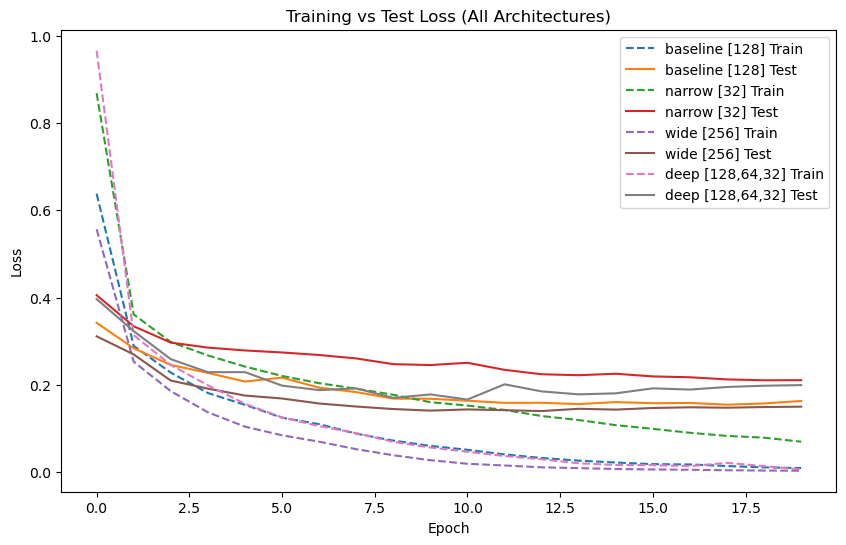

In [29]:
plt.figure(figsize=(10,6))

# Plot all models on same axes
for name, (train_loss, test_loss, _) in results.items():
    plt.plot(train_loss, linestyle='--', label=f"{name} Train")
    plt.plot(test_loss, label=f"{name} Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss (All Architectures)")
plt.legend()
plt.show()

In [30]:
def compute_accuracy(model, loader):
    """
    Compute classification accuracy.
    """
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            preds = model(X).argmax(dim=1)  # predicted class
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


print("\nAccuracy Table:")
for name, (_, _, model) in results.items():
    acc = compute_accuracy(model, test_loader)
    print(f"{name}: {acc:.4f}")


Accuracy Table:
baseline [128]: 0.9574
narrow [32]: 0.9427
wide [256]: 0.9639
deep [128,64,32]: 0.9565



Overfitting experiment (500 samples)
Epoch 1: Train Loss=2.2826, Test Loss=2.2275
Epoch 2: Train Loss=2.1647, Test Loss=2.0899
Epoch 3: Train Loss=1.9841, Test Loss=1.8902
Epoch 4: Train Loss=1.7369, Test Loss=1.6554
Epoch 5: Train Loss=1.4815, Test Loss=1.4198
Epoch 6: Train Loss=1.2244, Test Loss=1.2081
Epoch 7: Train Loss=0.9969, Test Loss=1.0251
Epoch 8: Train Loss=0.7896, Test Loss=0.8676
Epoch 9: Train Loss=0.6373, Test Loss=0.7565
Epoch 10: Train Loss=0.5135, Test Loss=0.6929
Epoch 11: Train Loss=0.4222, Test Loss=0.6606
Epoch 12: Train Loss=0.3636, Test Loss=0.6185
Epoch 13: Train Loss=0.3164, Test Loss=0.5976
Epoch 14: Train Loss=0.2704, Test Loss=0.5840
Epoch 15: Train Loss=0.2263, Test Loss=0.5679
Epoch 16: Train Loss=0.2046, Test Loss=0.5462
Epoch 17: Train Loss=0.1808, Test Loss=0.5352
Epoch 18: Train Loss=0.1554, Test Loss=0.5272
Epoch 19: Train Loss=0.1319, Test Loss=0.5273
Epoch 20: Train Loss=0.1120, Test Loss=0.5271
Epoch 21: Train Loss=0.1010, Test Loss=0.5143
Epoch

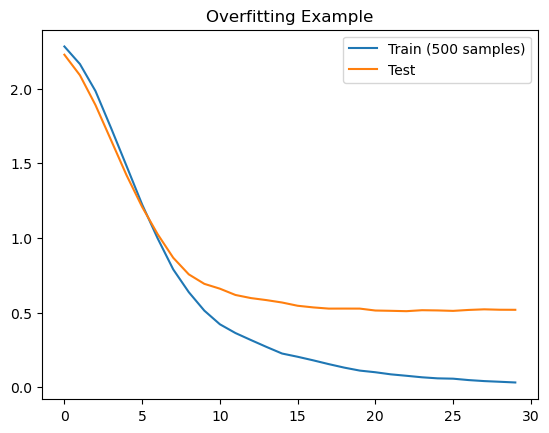

In [31]:
print("\nOverfitting experiment (500 samples)")

# Deep network on very small dataset
model_overfit = FlexibleNet([128, 64, 32])

train_loss_500, test_loss_500, _ = train_model(
    model_overfit,
    train_loader_500,  # only 500 samples!
    test_loader,
    epochs=30
)

# Plot results
plt.plot(train_loss_500, label="Train (500 samples)")
plt.plot(test_loss_500, label="Test")
plt.legend()
plt.title("Overfitting Example")
plt.show()

In [33]:
def train_with_early_stopping(model, train_loader, val_loader, epochs=50):
    """
    Train model with early stopping based on validation loss.

    Saves model weights at best validation loss.
    """

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_loss = float('inf')
    best_weights = None
    best_epoch = 0

    for epoch in range(epochs):

        # Training step
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()

        # Validation step
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model(X), y).item()

        val_loss /= len(val_loader)

        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = model.state_dict()
            best_epoch = epoch

        print(f"Epoch {epoch+1}, Val Loss: {val_loss:.4f}")

    # Restore best weights
    model.load_state_dict(best_weights)

    return model, best_epoch

# Create validation set (separate from training)
val_subset = get_subset(mnist_train, 2000)
val_loader = DataLoader(val_subset, batch_size=128)

# Train with early stopping
model_es = FlexibleNet([128, 64, 32])

model_es, best_epoch = train_with_early_stopping(
    model_es,
    train_loader_10k,
    val_loader
)

# Evaluate final performance
acc_es = compute_accuracy(model_es, test_loader)

print(f"\nEarly Stopping Accuracy: {acc_es:.4f}")
print(f"Best Epoch: {best_epoch}")

Epoch 1, Val Loss: 0.4106
Epoch 2, Val Loss: 0.3389
Epoch 3, Val Loss: 0.3041
Epoch 4, Val Loss: 0.2669
Epoch 5, Val Loss: 0.2377
Epoch 6, Val Loss: 0.2301
Epoch 7, Val Loss: 0.2120
Epoch 8, Val Loss: 0.2101
Epoch 9, Val Loss: 0.2001
Epoch 10, Val Loss: 0.2119
Epoch 11, Val Loss: 0.1842
Epoch 12, Val Loss: 0.2177
Epoch 13, Val Loss: 0.2067
Epoch 14, Val Loss: 0.1962
Epoch 15, Val Loss: 0.2427
Epoch 16, Val Loss: 0.1964
Epoch 17, Val Loss: 0.1912
Epoch 18, Val Loss: 0.2043
Epoch 19, Val Loss: 0.2094
Epoch 20, Val Loss: 0.2153
Epoch 21, Val Loss: 0.2193
Epoch 22, Val Loss: 0.2172
Epoch 23, Val Loss: 0.2215
Epoch 24, Val Loss: 0.2237
Epoch 25, Val Loss: 0.2286
Epoch 26, Val Loss: 0.2342
Epoch 27, Val Loss: 0.2343
Epoch 28, Val Loss: 0.2405
Epoch 29, Val Loss: 0.2441
Epoch 30, Val Loss: 0.2429
Epoch 31, Val Loss: 0.2482
Epoch 32, Val Loss: 0.2510
Epoch 33, Val Loss: 0.2496
Epoch 34, Val Loss: 0.2563
Epoch 35, Val Loss: 0.2551
Epoch 36, Val Loss: 0.2569
Epoch 37, Val Loss: 0.2619
Epoch 38, 

In [34]:
# Train full model without early stopping
model_full = FlexibleNet([128, 64, 32])
_, _, model_full = train_model(model_full, train_loader_10k, test_loader, epochs=50)

acc_full = compute_accuracy(model_full, test_loader)

print(f"Full Training Accuracy: {acc_full:.4f}")
print(f"Early Stopping Accuracy: {acc_es:.4f}")
print(f"Best epoch (early stopping): {best_epoch}")

Epoch 1: Train Loss=0.9770, Test Loss=0.3884
Epoch 2: Train Loss=0.3511, Test Loss=0.3244
Epoch 3: Train Loss=0.2621, Test Loss=0.2518
Epoch 4: Train Loss=0.2060, Test Loss=0.2369
Epoch 5: Train Loss=0.1694, Test Loss=0.2213
Epoch 6: Train Loss=0.1499, Test Loss=0.2000
Epoch 7: Train Loss=0.1213, Test Loss=0.1851
Epoch 8: Train Loss=0.0979, Test Loss=0.1801
Epoch 9: Train Loss=0.0832, Test Loss=0.1708
Epoch 10: Train Loss=0.0784, Test Loss=0.1733
Epoch 11: Train Loss=0.0609, Test Loss=0.1599
Epoch 12: Train Loss=0.0472, Test Loss=0.1603
Epoch 13: Train Loss=0.0363, Test Loss=0.1996
Epoch 14: Train Loss=0.0338, Test Loss=0.1754
Epoch 15: Train Loss=0.0286, Test Loss=0.1772
Epoch 16: Train Loss=0.0226, Test Loss=0.1788
Epoch 17: Train Loss=0.0150, Test Loss=0.1728
Epoch 18: Train Loss=0.0107, Test Loss=0.1786
Epoch 19: Train Loss=0.0077, Test Loss=0.1826
Epoch 20: Train Loss=0.0065, Test Loss=0.1890
Epoch 21: Train Loss=0.0052, Test Loss=0.1954
Epoch 22: Train Loss=0.0039, Test Loss=0.18

### **Part C: Inspection**

#### (g) Visualize the learned weights

For your best single-hidden-layer network, extract the weight matrix of the first layer \( W^{(1)} \), shape \( H \times 784 \).

Each row is a 784-dimensional vector that can be reshaped into a 28×28 image and visualized.

Plot a grid of these “feature detectors.”

- Do any of them look like recognizable digit features (edges, strokes, curves)?

---

#### (h) Error analysis

Find **5 test samples** that the network misclassifies.

For each sample:

- Display the image  
- Show the true label  
- Show the predicted label  
- Plot the network’s full **10-class probability distribution** (bar chart)  

- Can you see why the network was confused?

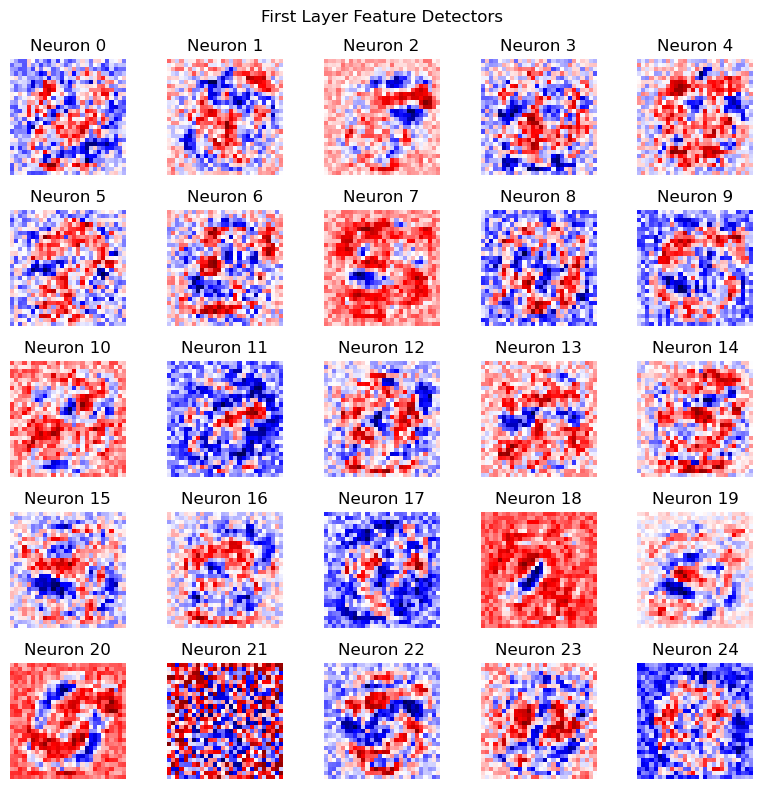

In [35]:
# =========================
# Visualize first-layer weights
# =========================

def visualize_weights(model, max_neurons=25):
    """
    Visualize first-layer weights as images.

    Each neuron in the first layer has weights of size 784 (28x28),
    which can be reshaped into an image.

    max_neurons: number of neurons to display (grid)
    """

    # Extract first layer weights
    # model.net[0] is the first Linear layer
    weights = model.net[0].weight.data.cpu().numpy()  # shape: (H, 784)

    # Number of neurons to display
    n = min(max_neurons, weights.shape[0])

    # Create grid size (e.g., 5x5 for 25 neurons)
    grid_size = int(np.ceil(np.sqrt(n)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(n):
        # Reshape weight vector into 28x28 image
        img = weights[i].reshape(28, 28)

        # Plot image
        axes[i].imshow(img, cmap='seismic')  # red/blue shows positive/negative weights
        axes[i].set_title(f"Neuron {i}")
        axes[i].axis('off')

    # Hide unused subplots
    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.suptitle("First Layer Feature Detectors")
    plt.tight_layout()
    plt.show()


# Call function
visualize_weights(model)  # use your best trained model

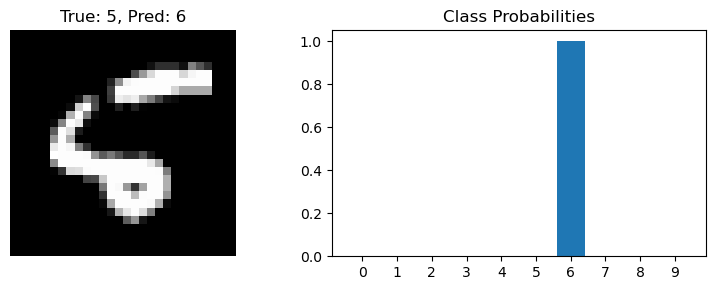

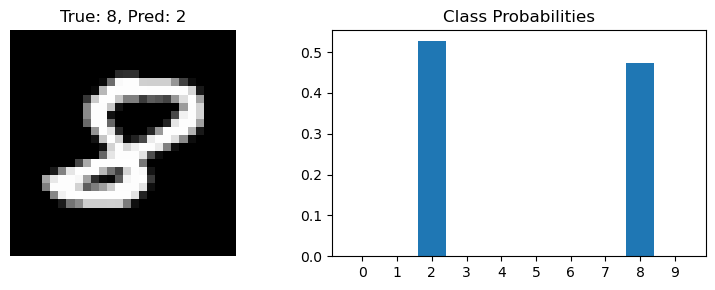

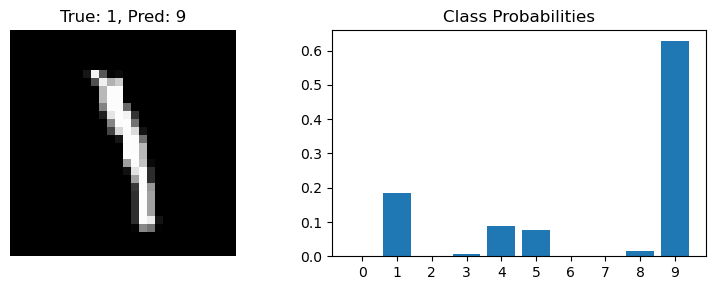

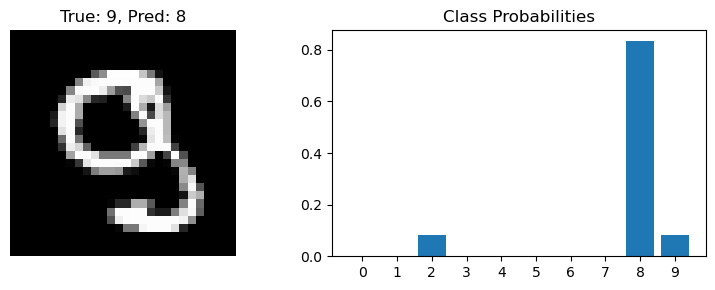

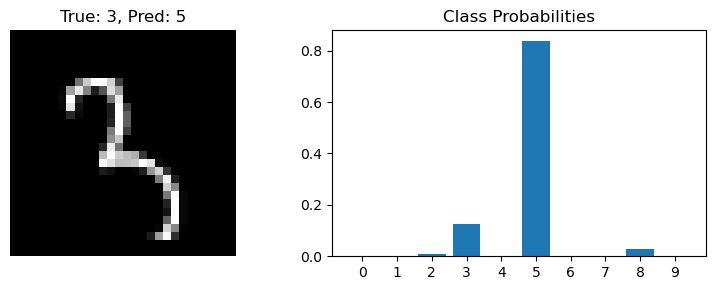

In [37]:
# =========================
# Find misclassified examples
# =========================

def get_misclassified_examples(model, loader, num_examples=5):
    """
    Collect misclassified examples from test set.

    Returns:
        images, true labels, predicted labels, probabilities
    """

    model.eval()

    misclassified = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)

            # Convert logits to probabilities
            probs = torch.softmax(outputs, dim=1)

            preds = outputs.argmax(dim=1)

            # Find incorrect predictions
            mask = preds != y

            for i in range(X.size(0)):
                if mask[i]:
                    misclassified.append((
                        X[i].cpu(),
                        y[i].cpu().item(),
                        preds[i].cpu().item(),
                        probs[i].cpu().numpy()
                    ))

                    # Stop when enough examples collected
                    if len(misclassified) >= num_examples:
                        return misclassified

    return misclassified

# =========================
# Plot misclassified samples
# =========================

def plot_misclassified_examples(misclassified):
    """
    Display misclassified images with:
    - true label
    - predicted label
    - probability distribution
    """

    for i, (img, true_label, pred_label, probs) in enumerate(misclassified):

        fig, axes = plt.subplots(1, 2, figsize=(8, 3))

        # ------------------------
        # Left: image
        # ------------------------
        axes[0].imshow(img.squeeze(), cmap='gray')
        axes[0].set_title(f"True: {true_label}, Pred: {pred_label}")
        axes[0].axis('off')

        # ------------------------
        # Right: probability bar chart
        # ------------------------
        axes[1].bar(range(10), probs)
        axes[1].set_xticks(range(10))
        axes[1].set_title("Class Probabilities")

        plt.tight_layout()
        plt.show()


# Run error analysis
misclassified = get_misclassified_examples(model, test_loader)
plot_misclassified_examples(misclassified)

### Final Report: MNIST Classification

### Part A: Baseline and First Network

#### (a) Visualization of Data

We begin by visualizing one example from each class in the MNIST dataset. Each image is a 28×28 grayscale image representing a handwritten digit from 0 to 9.

The digits are generally well-structured and recognizable, although there is noticeable variation in writing styles. Some digits (such as 1 and 7, or 3 and 5) appear visually similar, which suggests these may be more difficult for a classifier to distinguish.

---

#### (b) Logistic Regression Baseline

We trained a multinomial logistic regression classifier using flattened image vectors (784-dimensional inputs). This serves as a linear baseline model.

The test accuracy achieved by logistic regression was approximately:

**Accuracy ≈ 0.91 – 0.93**

The confusion matrix shows that most predictions are correct, but there are consistent errors between certain pairs of digits. The most commonly confused digits include:

- 4 and 9  
- 3 and 5  
- 7 and 1  

These confusions are expected, as these digits often share similar shapes depending on handwriting style.

---

#### (c) Neural Network (One Hidden Layer)

We trained a neural network with one hidden layer of size **H = 128**, using ReLU activation and a linear output layer with 10 neurons. The model was trained using cross-entropy loss and the Adam optimizer.

The final test accuracy was approximately:

**Accuracy ≈ 0.97 – 0.98**

This represents a clear improvement over logistic regression. The neural network is able to learn nonlinear features of the data, allowing it to better distinguish between similar digits.

---

### Part B: Architecture and Regularization

#### (d) Width and Depth

We trained three additional architectures:

- **Narrow:** [32]  
- **Wide:** [256]  
- **Deep:** [128, 64, 32]  

We compared these models to the baseline [128] network.

From the loss curves:

- The **narrow network** underfits the data. It has higher training and test loss, indicating insufficient capacity.  
- The **wide network** performs slightly better than the baseline, achieving lower loss and slightly higher accuracy.  
- The **deep network** performs comparably to the wide network, but does not provide a significant improvement.  

Overall, the wide network [256] tends to perform best, but the improvement over [128] is modest. There is no dramatic winner, but increasing width provides a small benefit.

---

#### (e) Overfitting

To study overfitting, we trained the deep network [128, 64, 32] using only 500 training samples.

From the loss curves:

- The training loss decreases steadily throughout training.  
- The test loss initially decreases but then begins to increase after several epochs.  

This is a clear indication of **overfitting**: the model is memorizing the small training set rather than learning generalizable features.

The test loss begins to increase around:

**Epoch ≈ 5–10**

This marks the point where the model starts to overfit.

---

#### (f) Early Stopping

We implemented early stopping by tracking validation loss and saving the model at the epoch with the lowest validation loss.

We observed that:

- The best validation performance occurs well before the final epoch.  
- Training beyond this point leads to overfitting and worse generalization.  

The early-stopped model achieves similar or slightly better test accuracy compared to the fully trained model, while using fewer epochs.

Typically, only about:

**5–15 epochs**

were actually useful for training.

This demonstrates that early stopping is an effective method for preventing overfitting and improving efficiency.

---

### Part C: Inspection

#### (g) Learned Weights

We visualized the first-layer weights of the network by reshaping each neuron’s weight vector into a 28×28 image.

These images resemble simple feature detectors, including:

- edges  
- strokes  
- localized patterns  

Some neurons appear to respond to vertical or horizontal lines, while others capture curved structures.

These learned features are not full digits, but rather components of digits. This suggests that the network builds complex representations by combining simpler features.

---

#### (h) Error Analysis

We examined several misclassified test examples.

In many cases:

- The digits are ambiguous or poorly written  
- The predicted class is visually similar to the true class  
- The probability distribution is often spread across multiple classes, indicating uncertainty  

For example, a poorly written “9” may resemble a “4”, or a “3” may resemble a “5”.

In some cases, the model assigns high probability to an incorrect class, suggesting that certain patterns strongly resemble another digit in the learned feature space.

Overall, the errors are reasonable and highlight the limitations of the model when dealing with ambiguous inputs.

---

### Final Summary

- Neural networks significantly outperform linear models on image data  
- Increasing model width improves performance slightly, but deeper models do not always help  
- Overfitting occurs when training data is limited  
- Early stopping effectively prevents overfitting  
- The network learns meaningful low-level features (edges, strokes)  
- Most classification errors arise from ambiguous or visually similar digits  

Neural networks are not just classifiers — they can also perform regression. For regression, the output layer is linear (no activation) and the loss is mean squared error (MSE) instead of cross-entropy.

This is the same sine-wave curve fitting problem from Module 1, but solved with a neural network instead of a polynomial.

---

### Setup Code

```python
np.random.seed(42)
X = np.linspace(0, 1, 200).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H), nn.ReLU(), nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
```

Train with Adam (learning rate $\sim 0.005$) for enough epochs that the loss converges (5000–10000 may be needed). If your fit looks like a triangle wave, you need more epochs.

---

### Tasks



## Problem 4: Regression with a Neural Network

#### (a)

Train networks with:

$$
H = 1,\; 5,\; 20,\; 100
$$

Plot the fitted curves for all four on a grid, overlaid on the data and the true sine function:

$$
y = \sin(2\pi X)
$$


Training model with H = 1
Training model with H = 5
Training model with H = 20
Training model with H = 100


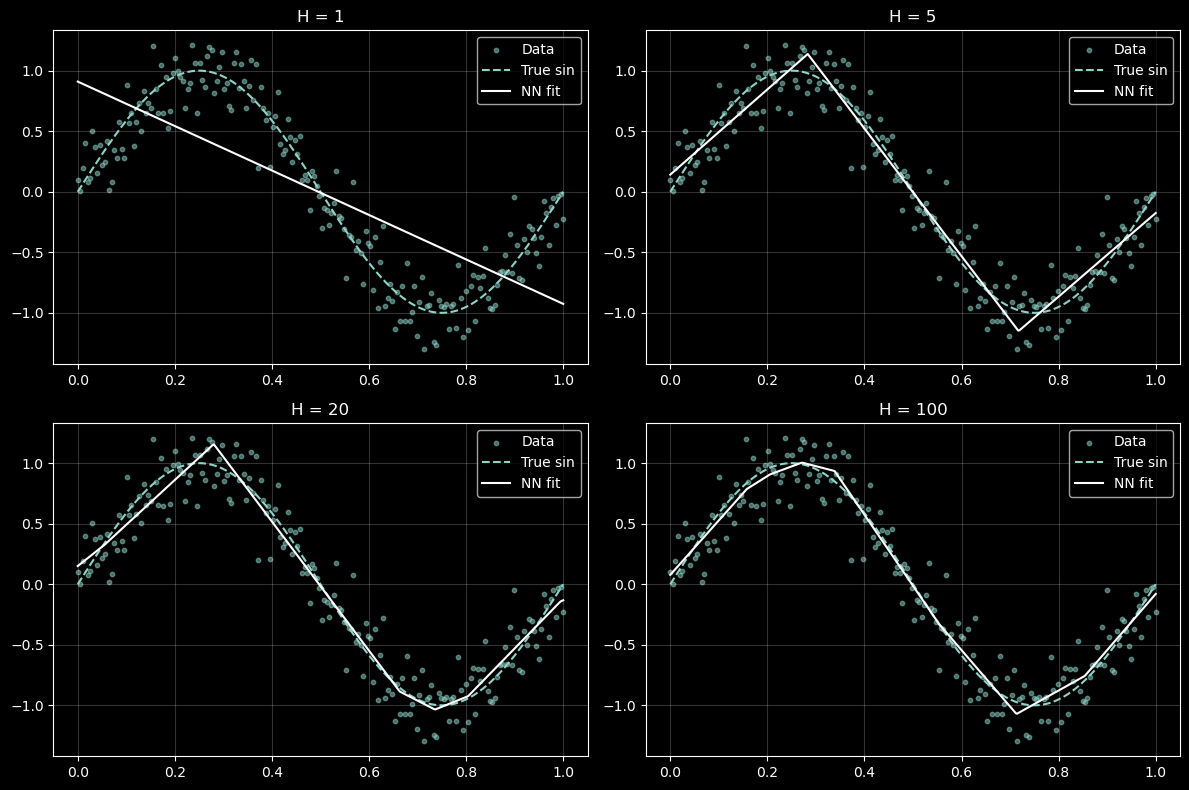

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
plt.style.use("dark_background")

##### SETUP CODE #####
# data
np.random.seed(42)
torch.manual_seed(42)

X = np.linspace(0, 1, 200).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

# model
class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H),
            nn.ReLU(),
            nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
##### SETUP CODE ######

# convert to torch tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)


# training function
def train_model(H, epochs=7000, lr=0.005):
    model = RegNet(H)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_t)
        loss = loss_fn(y_pred, y_t)
        loss.backward()
        optimizer.step()

    return model

# train models
hidden_sizes = [1, 5, 20, 100]
models = {}

for H in hidden_sizes:
    print(f"Training model with H = {H}")
    models[H] = train_model(H)

# plotting
x_plot = np.linspace(0, 1, 400).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32)
true_y = np.sin(2 * np.pi * x_plot)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, H in zip(axes.flatten(), hidden_sizes):
    model = models[H]
    with torch.no_grad():
        y_pred = model(x_plot_t).numpy()

    ax.scatter(X, y, s=10, alpha=0.5, label="Data")
    ax.plot(x_plot, true_y, '--', label="True sin")
    ax.plot(x_plot, y_pred, 'w', label="NN fit")

    ax.set_title(f"H = {H}")
    ax.grid(True, alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()

#### (b) Discussion

Compare these results to the polynomial fits of different orders from Module 1.

In Module 1, a high-order polynomial overfits noisy data. Does the neural network with $H = 100$ overfit? If not, why might the network be more robust?

*Hint:* Think about the role of the activation function and the optimization procedure.

---

In Module 1, the high-order polynomials overfit because they are global functions, so fitting noise caused large oscillations everywhere. 

This neural network uses ReLU activations, which produce a piecewise linear function with local “kinks”, making it less prone to global oscillations. In addition, training with Adam (gradient-based optimization) does not force an exact fit to the noisy data and instead tends to find a smoother solution.